In [1]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import sklearn

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

In [3]:
#Importing our dataset
stu = pd.read_excel("Capstone_dataset.xlsx")

In [4]:
stu

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13998,30,62,0,1,1,1,0,22,2,2,1,100,71,1,2,1
13999,30,62,0,1,1,1,0,23,3,12,1,72,55,1,1,2
14000,22,90,2,0,1,1,0,23,3,0,1,80,56,0,0,2
14001,22,90,2,0,1,1,0,29,2,16,0,50,62,1,2,2


In [5]:
stu.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [6]:
stu.tail()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
13998,30,62,0,1,1,1,0,22,2,2,1,100,71,1,2,1
13999,30,62,0,1,1,1,0,23,3,12,1,72,55,1,1,2
14000,22,90,2,0,1,1,0,23,3,0,1,80,56,0,0,2
14001,22,90,2,0,1,1,0,29,2,16,0,50,62,1,2,2
14002,10,86,2,1,2,1,0,18,2,8,1,66,77,1,2,1


In [7]:
stu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [8]:
stu.describe()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [9]:
#Checking for missing values
stu.isnull().sum()

StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

In [10]:
stu[stu.duplicated()]


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
12,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
13,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
14,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
21,24,98,1,1,1,1,1,29,0,3,0,65,46,1,2,3
22,24,98,1,1,1,1,1,27,0,0,1,71,83,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13569,29,72,1,0,0,1,0,18,1,14,1,66,55,1,2,2
13852,27,76,2,1,1,1,0,28,3,3,0,90,94,0,0,0
13853,27,76,2,1,1,1,0,25,0,1,0,63,77,1,0,1
13878,15,94,1,1,0,1,0,20,2,6,0,66,45,1,2,3


In [11]:
stu.duplicated().sum()

np.int64(1534)

In [12]:
stu =stu.drop_duplicates()
print(f"Remaining unique rows: {stu.shape[0]}")

Remaining unique rows: 12469


In [13]:
#Check for unique values
print(stu["Gender"].unique())
print(stu["LearningStyle"].unique())
print(stu["StressLevel"].unique())
print(stu["FinalGrade"].unique())
print(stu["Attendance"].unique())
print(stu["StudyHours"].unique())


[0 1]
[2 3 1 0]
[1 2 0]
[3 2 0 1]
[ 64  98  89  92  84  78  94  80  97  83  82  68  70  75  99  74  65  62
  91  90  66  69  60  72  61  86  77  71  67  88  87  73  96  81  95  63
  79 100  85  76  93]
[19 24 29 25 17 23 21  9 10 22 15 12 20 11 13 16 18 31 14  8 26 28 35 27
 36 43 33 30  7 32  6 38  5 34 39 37 44]


In [14]:
stu.insert(0, "studentID", ["STU" + str(i).zfill(5) for i in range(1, len(stu)+1)])


In [15]:
#Processing and logical phase
def assign_risk(grade):
    if grade == 0:
        return "High Risk"
    elif grade == 1:
        return "Medium Risk"
    elif grade == 2:
        return "Low Risk"
    else:
        return "Very Low Risk"
    
    stu["RiskLevel"] = stu["FinalGrade"].apply(assign_risk)


In [16]:
stu = stu.copy()   # ensures it’s a standalone DataFrame
stu['RiskLevel'] = stu['FinalGrade'].apply(assign_risk)

In [17]:
stu

,studentID,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade,RiskLevel
0,STU00001,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3,Very Low Risk
1,STU00002,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2,Low Risk
2,STU00003,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0,High Risk
3,STU00004,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3,Very Low Risk
4,STU00005,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13998,STU12465,30,62,0,1,1,1,0,22,2,2,1,100,71,1,2,1,Medium Risk
13999,STU12466,30,62,0,1,1,1,0,23,3,12,1,72,55,1,1,2,Low Risk
14000,STU12467,22,90,2,0,1,1,0,23,3,0,1,80,56,0,0,2,Low Risk
14001,STU12468,22,90,2,0,1,1,0,29,2,16,0,50,62,1,2,2,Low Risk


In [18]:
stu = pd.get_dummies(stu, columns=["LearningStyle"], drop_first=True)


In [19]:
print([col for col in stu.columns if "learn" in col.lower()])


['LearningStyle_1', 'LearningStyle_2', 'LearningStyle_3']


In [20]:
stu

,studentID,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade,RiskLevel,LearningStyle_1,LearningStyle_2,LearningStyle_3
0,STU00001,19,64,1,0,0,1,0,19,8,1,59,40,0,1,3,Very Low Risk,False,True,False
1,STU00002,19,64,1,0,0,1,0,23,16,0,90,66,0,1,2,Low Risk,False,False,True
2,STU00003,19,64,1,0,0,1,0,28,19,0,67,99,1,1,0,High Risk,True,False,False
3,STU00004,19,64,1,1,0,1,0,19,8,1,59,40,0,1,3,Very Low Risk,False,True,False
4,STU00005,19,64,1,1,0,1,0,23,16,0,90,66,0,1,2,Low Risk,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13998,STU12465,30,62,0,1,1,1,0,22,2,1,100,71,1,2,1,Medium Risk,False,True,False
13999,STU12466,30,62,0,1,1,1,0,23,12,1,72,55,1,1,2,Low Risk,False,False,True
14000,STU12467,22,90,2,0,1,1,0,23,0,1,80,56,0,0,2,Low Risk,False,False,True
14001,STU12468,22,90,2,0,1,1,0,29,16,0,50,62,1,2,2,Low Risk,False,True,False


In [21]:
stu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12469 entries, 0 to 14002
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   studentID             12469 non-null  object
 1   StudyHours            12469 non-null  int64 
 2   Attendance            12469 non-null  int64 
 3   Resources             12469 non-null  int64 
 4   Extracurricular       12469 non-null  int64 
 5   Motivation            12469 non-null  int64 
 6   Internet              12469 non-null  int64 
 7   Gender                12469 non-null  int64 
 8   Age                   12469 non-null  int64 
 9   OnlineCourses         12469 non-null  int64 
 10  Discussions           12469 non-null  int64 
 11  AssignmentCompletion  12469 non-null  int64 
 12  ExamScore             12469 non-null  int64 
 13  EduTech               12469 non-null  int64 
 14  StressLevel           12469 non-null  int64 
 15  FinalGrade            12469 non-null  int

In [22]:
stu.rename(columns={"EduTech": "EDTech_Usage_Level"}, inplace=True)

In [23]:
print(stu.columns)

Index(['studentID', 'StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'OnlineCourses',
       'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EDTech_Usage_Level', 'StressLevel', 'FinalGrade', 'RiskLevel',
       'LearningStyle_1', 'LearningStyle_2', 'LearningStyle_3'],
      dtype='object')


In [24]:
print(stu['RiskLevel'].unique())

['Very Low Risk' 'Low Risk' 'High Risk' 'Medium Risk']


In [25]:
#Esure any hidden space are removed
stu['RiskLevel'] = stu['RiskLevel'].str.strip()

# Define the dictionary (The 'Map')
correct_risk_map = {
    'Very Low Risk': 3, 
    'Low Risk': 2, 
    'Medium Risk': 1, 
    'High Risk': 0
}

# Apply it to the column
stu['RiskLevel'] = stu['RiskLevel'].map(correct_risk_map)

# Verify it worked
print(stu['RiskLevel'].value_counts())

RiskLevel
0    3401
2    3221
1    2943
3    2904
Name: count, dtype: int64


In [26]:
stu.RiskLevel

0        3
1        2
2        0
3        3
4        2
        ..
13998    1
13999    2
14000    2
14001    2
14002    1
Name: RiskLevel, Length: 12469, dtype: int64

In [27]:
print("Unique values in RiskLevel:", stu['RiskLevel'].unique())
print("\nCounts of each value:")
print(stu['RiskLevel'].value_counts())

Unique values in RiskLevel: [3 2 0 1]

Counts of each value:
RiskLevel
0    3401
2    3221
1    2943
3    2904
Name: count, dtype: int64


In [28]:
bool_cols = stu.select_dtypes(include='bool').columns
stu[bool_cols] = stu[bool_cols].astype(int)

In [29]:
stu['RiskLevel'] = stu['RiskLevel'].fillna(0).astype(int)

In [30]:
stu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12469 entries, 0 to 14002
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   studentID             12469 non-null  object
 1   StudyHours            12469 non-null  int64 
 2   Attendance            12469 non-null  int64 
 3   Resources             12469 non-null  int64 
 4   Extracurricular       12469 non-null  int64 
 5   Motivation            12469 non-null  int64 
 6   Internet              12469 non-null  int64 
 7   Gender                12469 non-null  int64 
 8   Age                   12469 non-null  int64 
 9   OnlineCourses         12469 non-null  int64 
 10  Discussions           12469 non-null  int64 
 11  AssignmentCompletion  12469 non-null  int64 
 12  ExamScore             12469 non-null  int64 
 13  EDTech_Usage_Level    12469 non-null  int64 
 14  StressLevel           12469 non-null  int64 
 15  FinalGrade            12469 non-null  int

In [31]:
stu[stu.duplicated()]


,studentID,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EDTech_Usage_Level,StressLevel,FinalGrade,RiskLevel,LearningStyle_1,LearningStyle_2,LearningStyle_3


In [32]:
stu.shape


(12469, 20)

In [33]:
#Checking Final distribution
stu["RiskLevel"].value_counts()


RiskLevel
0    3401
2    3221
1    2943
3    2904
Name: count, dtype: int64

In [34]:
def generate_intervention(student_data, risk_level):
    """
    Generates personalized intervention recommendations
    based on student behavioral data and predicted risk level.
    """

    interventions = []

    #Threshold Configuration
    LOW_EDTECH_THRESHOLD = 4
    HIGH_STRESS_THRESHOLD = 7
    LOW_ATTENDANCE_THRESHOLD = 75

    # --- Risk-Based Priority Intervention ---
    if risk_level == "High":
        interventions.append(
            "Immediate academic counseling and weekly progress monitoring required."
        )

    elif risk_level == "Medium":
        interventions.append(
            "Assign structured study plan and academic mentor support."
        )

    #  Behavioral-Based Interventions
    if student_data.get("EdTech_Usage_Level", 10) < LOW_EDTECH_THRESHOLD:
        interventions.append(
            "Encourage increased engagement with approved digital learning platforms."
        )

    if student_data.get("StressLevel", 0) > HIGH_STRESS_THRESHOLD:
        interventions.append(
            "Schedule stress management session with school counselor."
        )

    if student_data.get("Attendance", 100) < LOW_ATTENDANCE_THRESHOLD:
        interventions.append(
            "Initiate attendance review and organize parent-teacher discussion."
        )

    #Default Message
    if not interventions:
        interventions.append(
            "Maintain current academic habits and continue regular monitoring."
        )

    return interventions

In [35]:
stu.columns

Index(['studentID', 'StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'OnlineCourses',
       'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EDTech_Usage_Level', 'StressLevel', 'FinalGrade', 'RiskLevel',
       'LearningStyle_1', 'LearningStyle_2', 'LearningStyle_3'],
      dtype='object')

In [36]:
def performance_support(student_data):

    PERFORMANCE_THRESHOLD = 70

    if student_data["FinalGrade"] < PERFORMANCE_THRESHOLD:
        return {
            "show_poll": True,
            "poll_question": "What is affecting your performance?",
            "options": [
                "Difficulty understanding course material",
                "Lack of study time",
                "Personal or family issues",
                "Stress or mental health concerns",
                "Poor internet or technology access"
            ]
        }

    return {"show_poll": False}

In [37]:
def generate_encouragement(reason):

    messages = {
        "Difficulty understanding course material":
            "You're not alone. Consider attending extra tutorials and asking questions during class.",
        
        "Lack of study time":
            "Small daily study sessions can make a big difference. Try creating a simple study schedule.",
        
        "Personal or family issues":
            "Support is available. Speak with a counselor or trusted mentor.",
        
        "Stress or mental health concerns":
            "Your wellbeing matters. Consider speaking with the school counselor.",
        
        "Poor internet or technology access":
            "Discuss alternative learning resources with your academic advisor."
    }

    return messages.get(reason, "Keep pushing forward. Improvement is possible with consistent effort.")

In [38]:
stu.to_csv("Cleaned_Student_data.csv",)


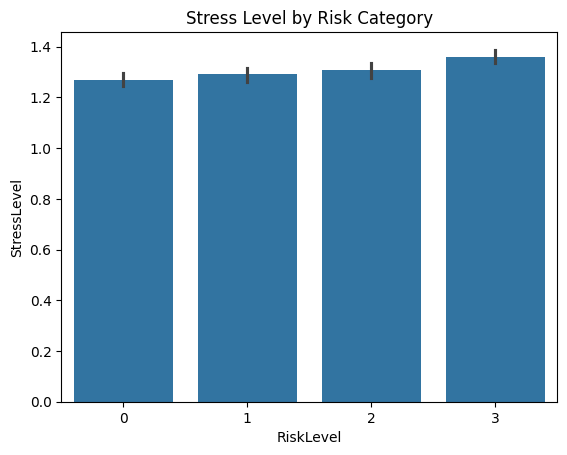

In [39]:
sns.barplot(x = "RiskLevel", y = "StressLevel", data=stu)
plt.title("Stress Level by Risk Category")
plt.show()

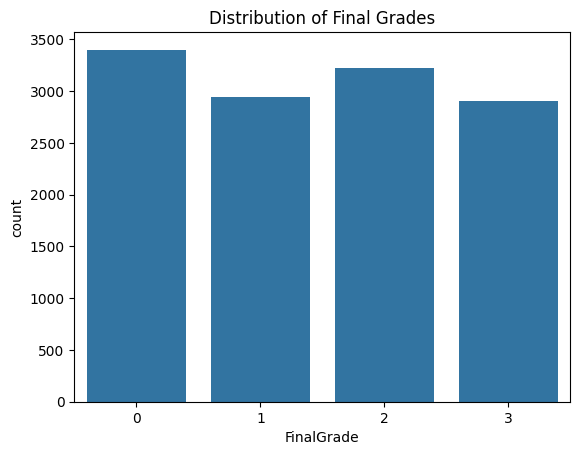

In [40]:
sns.countplot(x="FinalGrade", data=stu)
plt.title("Distribution of Final Grades")
plt.show()

In [41]:
stu.head()

,studentID,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EDTech_Usage_Level,StressLevel,FinalGrade,RiskLevel,LearningStyle_1,LearningStyle_2,LearningStyle_3
0,STU00001,19,64,1,0,0,1,0,19,8,1,59,40,0,1,3,3,0,1,0
1,STU00002,19,64,1,0,0,1,0,23,16,0,90,66,0,1,2,2,0,0,1
2,STU00003,19,64,1,0,0,1,0,28,19,0,67,99,1,1,0,0,1,0,0
3,STU00004,19,64,1,1,0,1,0,19,8,1,59,40,0,1,3,3,0,1,0
4,STU00005,19,64,1,1,0,1,0,23,16,0,90,66,0,1,2,2,0,0,1


In [42]:
stu

,studentID,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EDTech_Usage_Level,StressLevel,FinalGrade,RiskLevel,LearningStyle_1,LearningStyle_2,LearningStyle_3
0,STU00001,19,64,1,0,0,1,0,19,8,1,59,40,0,1,3,3,0,1,0
1,STU00002,19,64,1,0,0,1,0,23,16,0,90,66,0,1,2,2,0,0,1
2,STU00003,19,64,1,0,0,1,0,28,19,0,67,99,1,1,0,0,1,0,0
3,STU00004,19,64,1,1,0,1,0,19,8,1,59,40,0,1,3,3,0,1,0
4,STU00005,19,64,1,1,0,1,0,23,16,0,90,66,0,1,2,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13998,STU12465,30,62,0,1,1,1,0,22,2,1,100,71,1,2,1,1,0,1,0
13999,STU12466,30,62,0,1,1,1,0,23,12,1,72,55,1,1,2,2,0,0,1
14000,STU12467,22,90,2,0,1,1,0,23,0,1,80,56,0,0,2,2,0,0,1
14001,STU12468,22,90,2,0,1,1,0,29,16,0,50,62,1,2,2,2,0,1,0


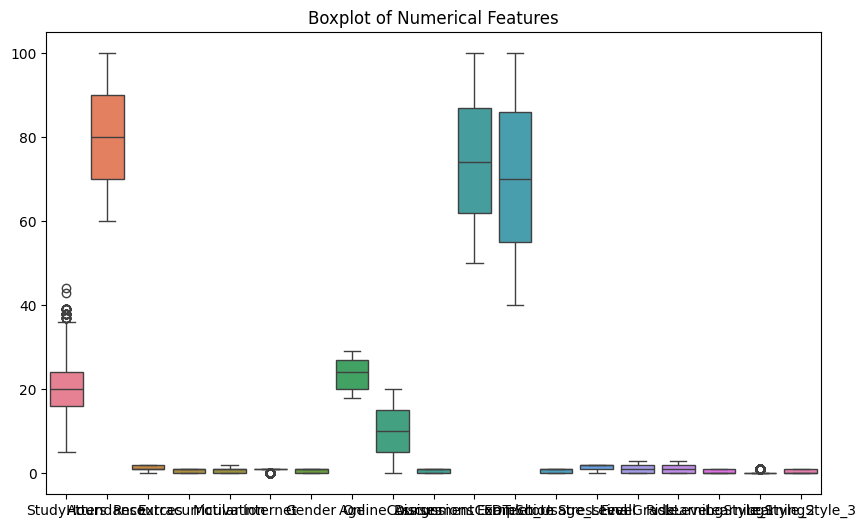

In [43]:
#Checking for outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=stu)
plt.title("Boxplot of Numerical Features")
plt.show()


In [44]:
#  Select only the numeric columns for the math
numeric_stu = stu.select_dtypes(include=['number'])

# Calculate IQR only on those numbers
Q1 = numeric_stu.quantile(0.25)
Q3 = numeric_stu.quantile(0.75)
IQR = Q3 - Q1

# Filter the original data using the numeric logic
stu = stu[~((numeric_stu < (Q1 - 1.5 * IQR)) | (numeric_stu > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Data cleaned! New row count: {stu.shape[0]}")

Data cleaned! New row count: 8563


<Axes: >

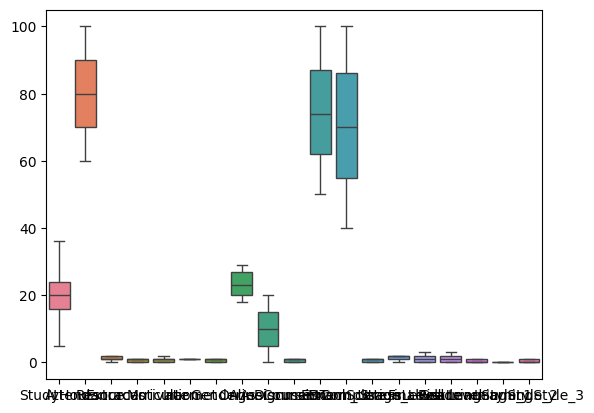

In [45]:
sns.boxplot(data=stu)


In [46]:
x = stu.drop(columns=['ExamScore', 'studentID', 'FinalGrade', 'RiskLevel'])
y = stu['RiskLevel']

In [47]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [48]:
Pipeline = Pipeline([("scaler", StandardScaler()), ("model", RandomForestClassifier(random_state=42))])


In [49]:
Pipeline.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [50]:
print(x.columns)


Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'OnlineCourses',
       'Discussions', 'AssignmentCompletion', 'EDTech_Usage_Level',
       'StressLevel', 'LearningStyle_1', 'LearningStyle_2', 'LearningStyle_3'],
      dtype='object')


In [51]:
print(classification_report)


<function classification_report at 0x000002AC48650F60>


In [52]:
from sklearn.model_selection import train_test_split

# Split the clean data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Re-train the model
Pipeline.fit(x_train, y_train)

# Get new predictions
y_pred = Pipeline.predict(x_test)

In [53]:
#Evaluating the Model
y_pred = Pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nclassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8873321657910099

classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       496
           1       0.89      0.83      0.86       400
           2       0.88      0.92      0.90       429
           3       0.90      0.89      0.90       388

    accuracy                           0.89      1713
   macro avg       0.89      0.89      0.89      1713
weighted avg       0.89      0.89      0.89      1713



In [54]:

stu.columns

Index(['studentID', 'StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'OnlineCourses',
       'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EDTech_Usage_Level', 'StressLevel', 'FinalGrade', 'RiskLevel',
       'LearningStyle_1', 'LearningStyle_2', 'LearningStyle_3'],
      dtype='object')

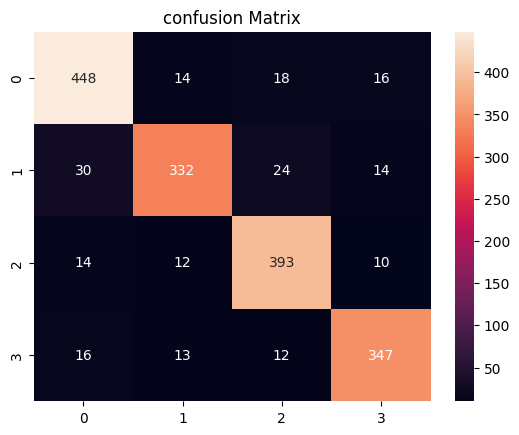

In [55]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("confusion Matrix")
plt.show()

In [56]:
print(y_train.value_counts())
print(y_test.value_counts())

RiskLevel
0    1840
2    1745
3    1670
1    1595
Name: count, dtype: int64
RiskLevel
0    496
2    429
1    400
3    388
Name: count, dtype: int64


In [57]:
#Improving the Model(Hyperparameter Tuning)
param_grid ={"model__n_estimators": [100,200], "model__max_depth": [None, 10, 20]}

grid =GridSearchCV(Pipeline, param_grid, cv=3, scoring="accuracy")
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': None, 'model__n_estimators': 200}


In [58]:
best_model =grid.best_estimator_


In [59]:
#Final Evaluation
y_pred_best = best_model.predict(x_test)
print("improved Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

improved Accuracy: 0.890251021599533
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       496
           1       0.91      0.83      0.87       400
           2       0.88      0.91      0.90       429
           3       0.90      0.90      0.90       388

    accuracy                           0.89      1713
   macro avg       0.89      0.89      0.89      1713
weighted avg       0.89      0.89      0.89      1713



In [60]:
#Feature Importance(Explainableility)
importances = best_model.named_steps["model"].feature_importances_
features = x.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                 Feature  Importance
10  AssignmentCompletion    0.168160
1             Attendance    0.159456
0             StudyHours    0.148538
8          OnlineCourses    0.143983
7                    Age    0.118940
12           StressLevel    0.044521
6                 Gender    0.033564
11    EDTech_Usage_Level    0.030550
2              Resources    0.028545
15       LearningStyle_3    0.028351


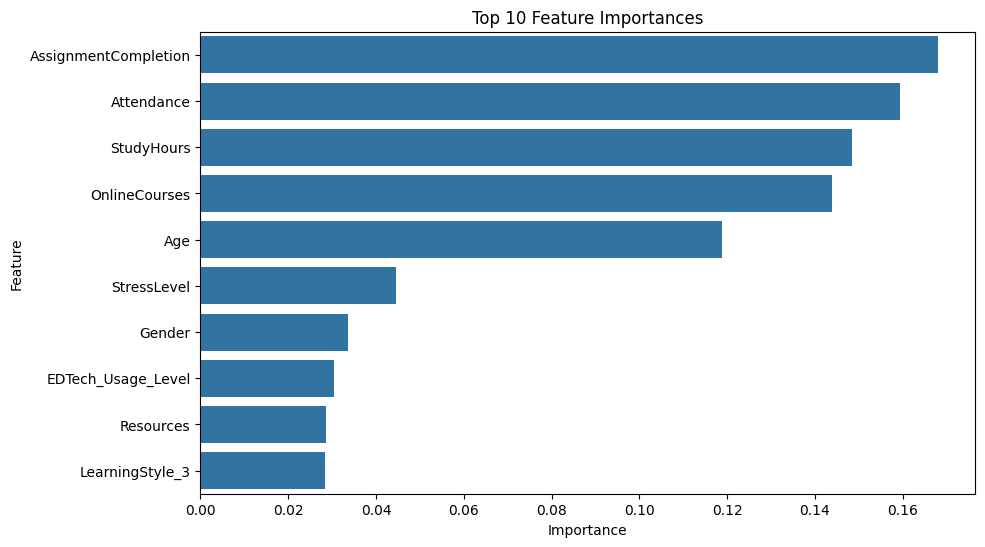

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

In [62]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best})
print(comparison_df.head(20))


       Actual  Predicted
12984       1          1
10089       0          0
2854        0          0
1225        0          0
3383        3          3
6148        3          3
405         2          2
11446       2          2
3674        3          3
5380        2          2
10897       1          1
1966        2          2
8929        2          3
7258        0          0
6987        3          3
10340       0          0
3402        3          3
3710        0          0
3454        3          3
8738        0          2


In [63]:
#Export Model
joblib.dump(best_model, "risk_model_pipeline.pkl")

['risk_model_pipeline.pkl']

In [64]:
#File created

loaded_model = joblib.load("risk_model_pipeline.pkl")
print("Model loaded successfully!")


Model loaded successfully!


In [65]:
from sklearn.ensemble import RandomForestClassifier
import joblib

#  Re-train with a 'max_depth' to stop the trees from getting too big
# Depth 10-15 usually keeps accuracy high but shrinks the file by 60-80%
final_forest = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)


Pipeline.set_params(model=final_forest)
Pipeline.fit(x_train, y_train)

#Save with maximum compression (compress=9)
joblib.dump(Pipeline, 'risk_model_final_v2.pkl', compress=9)

print("New model saved! Check the size in the sidebar.")

New model saved! Check the size in the sidebar.


In [66]:
from sklearn.metrics import accuracy_score, classification_report

# Get new predictions using the pruned model
y_pred_light = Pipeline.predict(x_test)

# Check the new accuracy
new_accuracy = accuracy_score(y_test, y_pred_light)
print(f"New 'Light' Model Accuracy: {new_accuracy:.4f}")

# Check if any specific grade levels suffered
print(classification_report(y_test, y_pred_light))

New 'Light' Model Accuracy: 0.8634
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       496
           1       0.90      0.79      0.84       400
           2       0.87      0.88      0.88       429
           3       0.86      0.89      0.87       388

    accuracy                           0.86      1713
   macro avg       0.87      0.86      0.86      1713
weighted avg       0.87      0.86      0.86      1713

